In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

 3. Load Dataset

In [2]:
df = pd.read_csv("P:/Data Science/Jupyter Notebook 2/Titanic-Dataset.csv")
print("\nDataset loaded successfully!")


Dataset loaded successfully!


 4. Display first and last 5 rows

In [3]:
print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())


First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

5. Dataset Shape

In [4]:
print("\nDataset Information")
print("-------------------")
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)


Dataset Information
-------------------
Number of Rows: 891
Number of Columns: 12


6. Column Name

In [5]:
print("\nColumns:")
for column in df.columns:
    print(column)


Columns:
PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked


7. Dataset Information

In [6]:

print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


8. StatisticalSummary

In [7]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


Missing Values

In [8]:

print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Check missing-value percentage

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

print(missing_table)

# Age
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)
print("Missing Age values:", df["Age"].isnull().sum())

# Embarked
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)
print("Missing Embarked values:", df["Embarked"].isnull().sum())

# Cabin
df["CabinKnown"] = df["Cabin"].notnull().astype(int)
print(df["CabinKnown"].value_counts())



             Missing Values  Percentage
PassengerId               0    0.000000
Survived                  0    0.000000
Pclass                    0    0.000000
Name                      0    0.000000
Sex                       0    0.000000
Age                     177   19.865320
SibSp                     0    0.000000
Parch                     0    0.000000
Ticket                    0    0.000000
Fare                      0    0.000000
Cabin                   687   77.104377
Embarked                  2    0.224467
Missing Age values: 0
Missing Embarked values: 0
CabinKnown
0    687
1    204
Name: count, dtype: int64


In [10]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
CabinKnown       0
dtype: int64


Create FamilySize

In [11]:
# Create FamilySize
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("Family Size:")
print(df[["SibSp", "Parch", "FamilySize"]].head(10))

Family Size:
   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1
6      0      0           1
7      3      1           5
8      0      2           3
9      1      0           2


In [12]:
# Create IsAlone
df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)

print("IsAlone:")
print(df[["FamilySize", "IsAlone"]].head(10))

IsAlone:
   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1
5           1        1
6           1        1
7           5        0
8           3        0
9           2        0


Create Age Group

In [13]:
# Create AgeGroup
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

print("Age Groups:")
print(df[["Age", "AgeGroup"]].head(10))

Age Groups:
    Age     AgeGroup
0  22.0  Young Adult
1  38.0        Adult
2  26.0  Young Adult
3  35.0  Young Adult
4  35.0  Young Adult
5  28.0  Young Adult
6  54.0        Adult
7   2.0        Child
8  27.0  Young Adult
9  14.0     Teenager


Create Family Category

In [14]:
# Create FamilyCategory

def family_category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small Family"
    else:
        return "Large Family"

df["FamilyCategory"] = df["FamilySize"].apply(family_category)

print("Family Categories:")
print(df[["FamilySize", "FamilyCategory"]].head(10))

Family Categories:
   FamilySize FamilyCategory
0           2   Small Family
1           2   Small Family
2           1          Alone
3           2   Small Family
4           1          Alone
5           1          Alone
6           1          Alone
7           5   Large Family
8           3   Small Family
9           2   Small Family


Check final columns

In [15]:
print("Final Columns:")
print(df.columns.tolist())

Final Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'CabinKnown', 'FamilySize', 'IsAlone', 'AgeGroup', 'FamilyCategory']


##### Basic Statistics

Dataset shape and Statistical summary

In [16]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
df.describe()


Number of Rows: 891
Number of Columns: 17


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,CabinKnown,FamilySize,IsAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,0.228956,1.904602,0.602694
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,0.420397,1.613459,0.489615
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,1.000000,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,0.000000,2.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,11.000000,1.000000


Survival count

In [17]:
survival_count = df["Survived"].value_counts()

print("Survival Count:")
print(survival_count)

Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64


Survival percentage

In [18]:
survival_percentage = df["Survived"].value_counts(normalize=True) * 100

print("Survival Percentage:")
print(survival_percentage)

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


##### Overall Survival Visualization

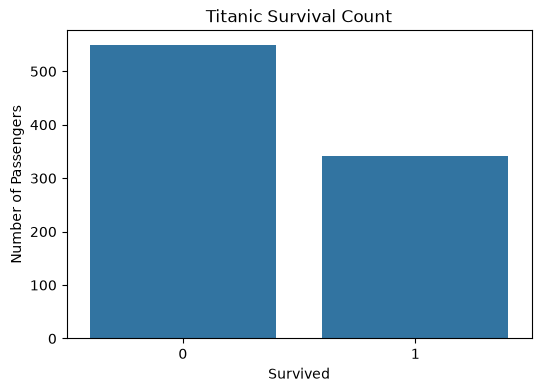

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Titanic Survival Count")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

##### Survival Percentage Pie Chart

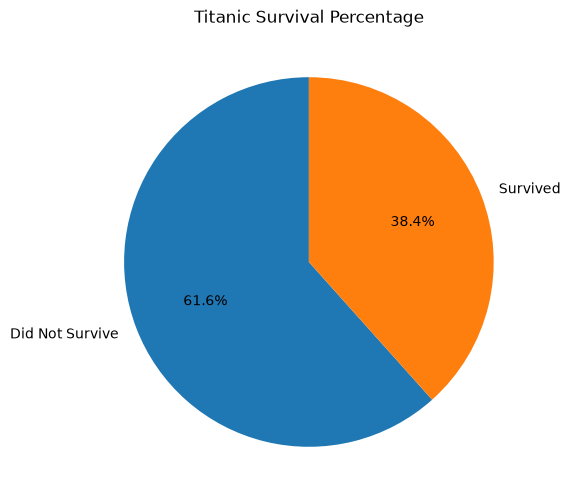

In [20]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Titanic Survival Percentage")

plt.show()

##### Gender Analysis

In [21]:
# Male and Female Count
print("Passenger Count by Gender:")
print(df["Sex"].value_counts())


Passenger Count by Gender:
Sex
male      577
female    314
Name: count, dtype: int64


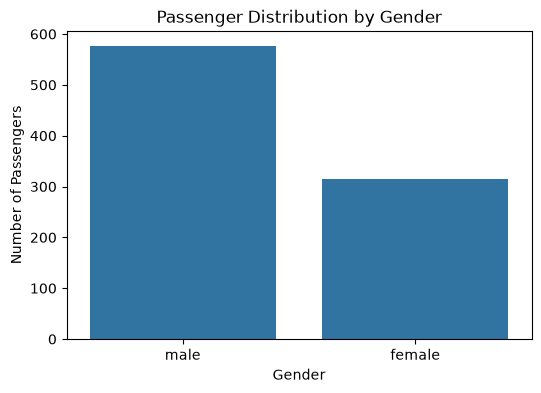

In [22]:
# Gender Distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex")

plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

##### Survival by Gender

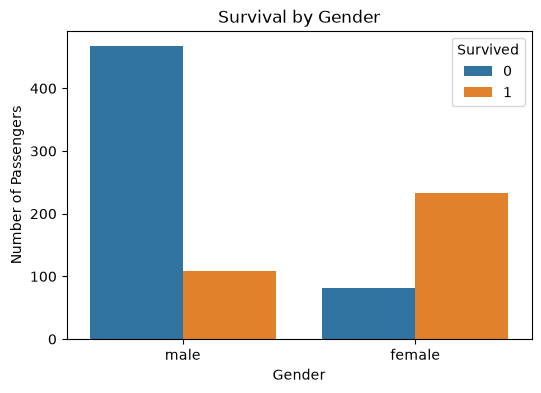

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

##### Passenger Class Analysis

In [24]:
# Passenger Count by Class
print("Passenger Count by Class:")
print(df["Pclass"].value_counts().sort_index())

Passenger Count by Class:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


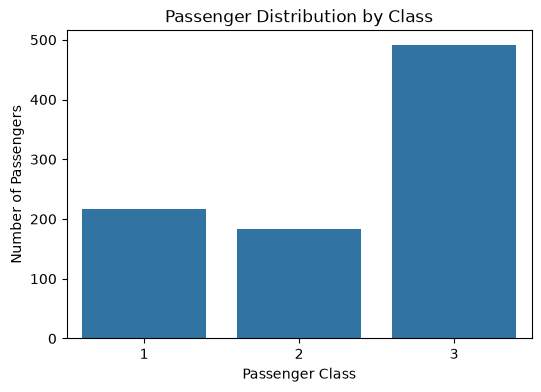

In [25]:
# Class Distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Pclass")

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

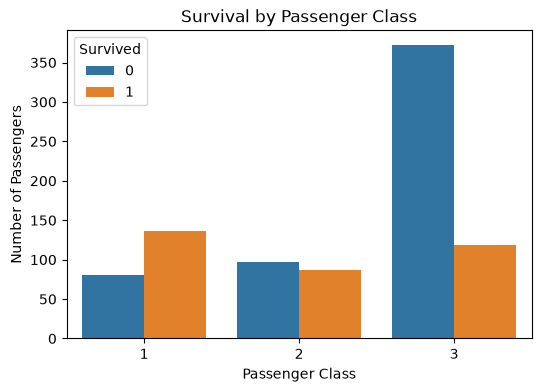

In [26]:
# Survival by Class
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

In [27]:
# Survival Rate by Class
class_survival = df.groupby("Pclass")["Survived"].mean() * 100
print("Survival Rate by Passenger Class:")
print(class_survival)

Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


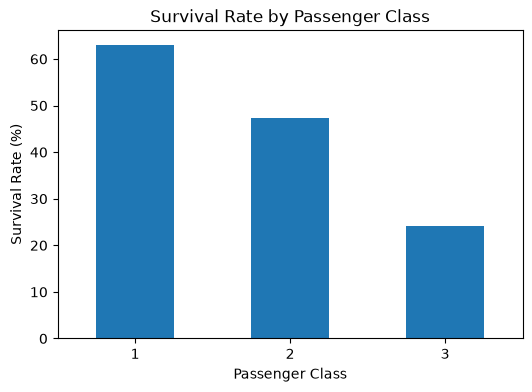

In [28]:
plt.figure(figsize=(6, 4))

class_survival.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")

plt.xticks(rotation=0)

plt.show()

##### Age Analysis

In [29]:
# Age Statistics
print("Age Statistics:")
print(df["Age"].describe())

Age Statistics:
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


In [30]:
# Survival Rate by Age Group
age_group_survival = df.groupby(
    "AgeGroup",
    observed=True
)["Survived"].mean() * 100

print("Survival Rate by Age Group:")
print(age_group_survival)

Survival Rate by Age Group:
AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


##### Fare Analysis

In [31]:
# Fare Statistics
print("Fare Statistics:")
print(df["Fare"].describe())

Fare Statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


proportion of passengers who survived and did not survive.

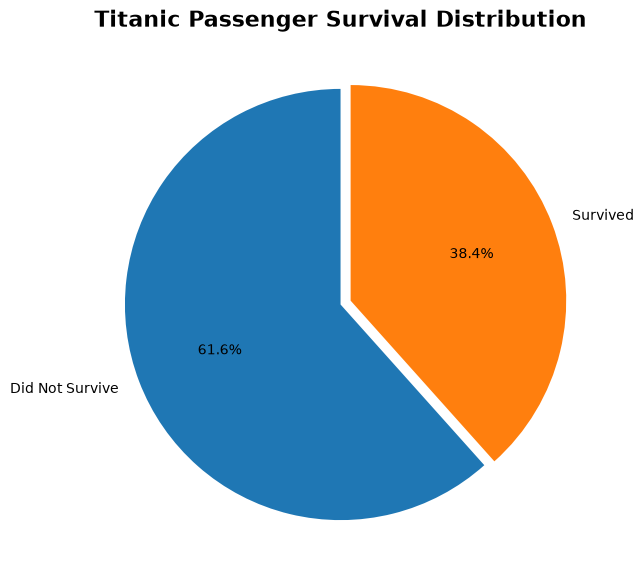

In [32]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0, 0.05]
)

plt.title(
    "Titanic Passenger Survival Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.show()

#### Survival Count

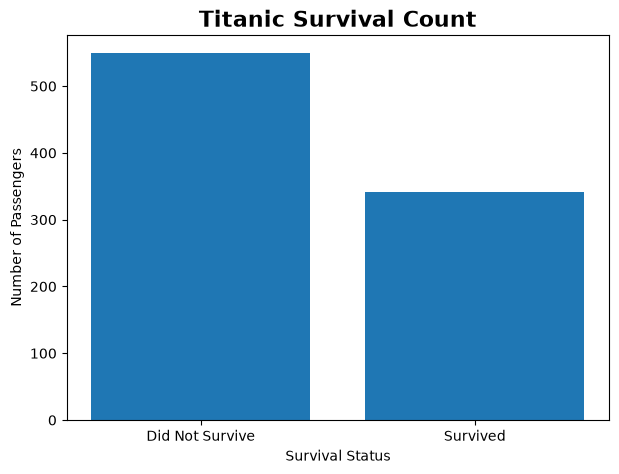

In [33]:
survival_counts = df["Survived"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Did Not Survive", "Survived"],
    survival_counts
)

plt.title(
    "Titanic Survival Count",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

Gender Distribution

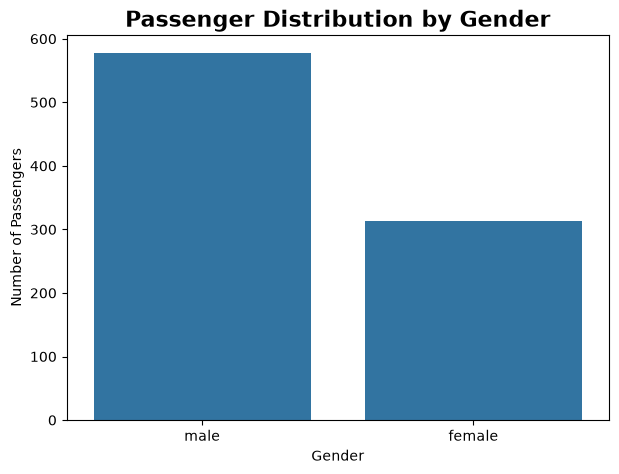

In [34]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Sex"
)

plt.title(
    "Passenger Distribution by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

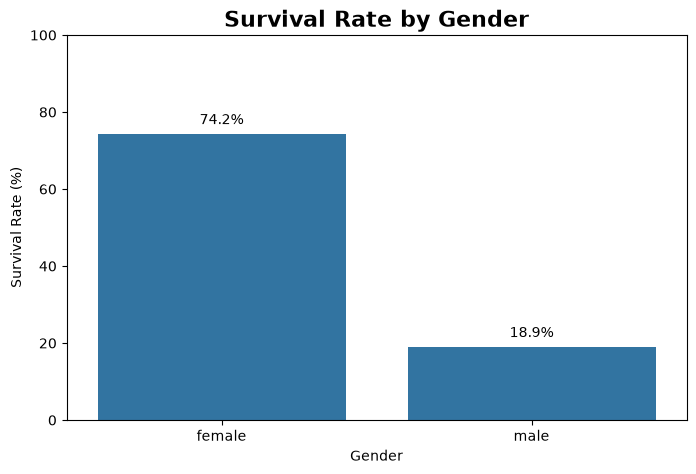

In [35]:
gender_survival = (
    df.groupby("Sex")["Survived"]
    .mean()
    .reset_index()
)

gender_survival["Survival Rate"] = (
    gender_survival["Survived"] * 100
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=gender_survival,
    x="Sex",
    y="Survival Rate"
)

plt.title(
    "Survival Rate by Gender",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")

plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5
    )

plt.show()

Passenger distribution by class

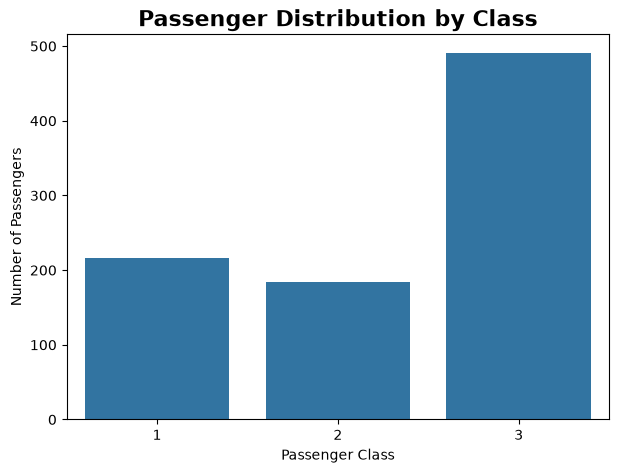

In [36]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Pclass"
)

plt.title(
    "Passenger Distribution by Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

Survival count by passenger class

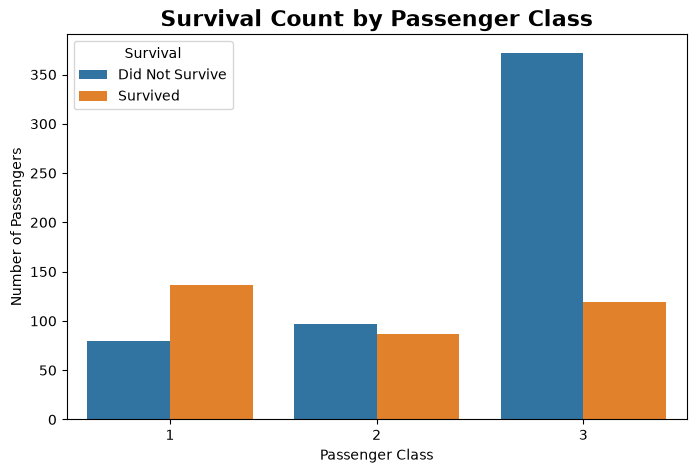

In [37]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title(
    "Survival Count by Passenger Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.legend(
    title="Survival",
    labels=["Did Not Survive", "Survived"]
)

plt.show()

2 Matplotlib Scatter Plot

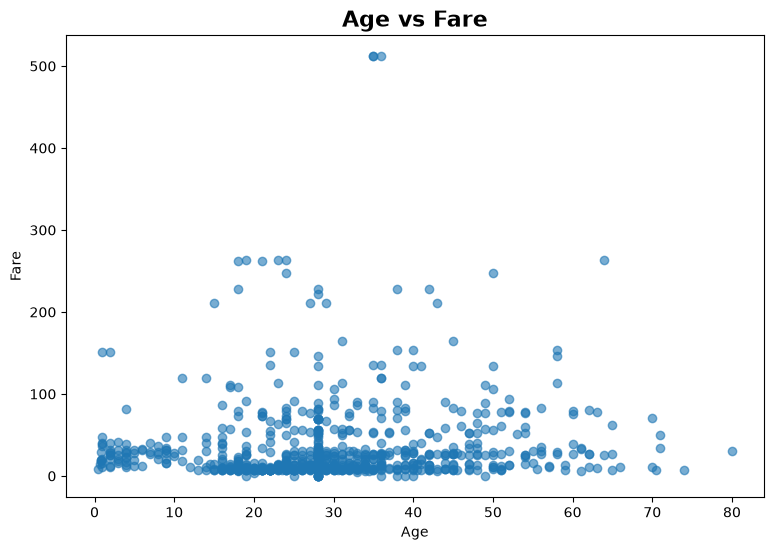

In [38]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Age"],
    df["Fare"],
    alpha=0.6
)

plt.title(
    "Age vs Fare",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

Matplotlib Histogram by Surviva

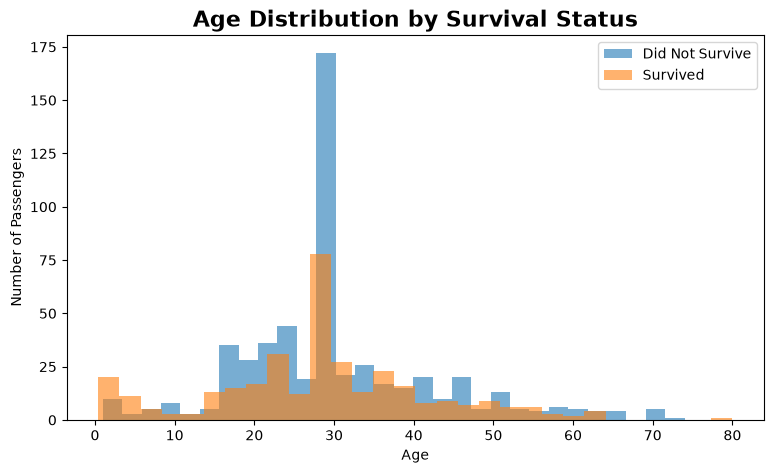

In [39]:
survived_age = df[df["Survived"] == 1]["Age"]
not_survived_age = df[df["Survived"] == 0]["Age"]

plt.figure(figsize=(9, 5))

plt.hist(
    not_survived_age,
    bins=30,
    alpha=0.6,
    label="Did Not Survive"
)

plt.hist(
    survived_age,
    bins=30,
    alpha=0.6,
    label="Survived"
)

plt.title(
    "Age Distribution by Survival Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.legend()

plt.show()